**Experiment 10: Implement an Ensemble Learner using Adaboost Algorithm using Python programming.**

**Aim:** To implement an ensemble learning model using the AdaBoost algorithm for classification and evaluate its performance using standard evaluation metrics.

**Overview of AdaBoost (Adaptive Boosting)**

**AdaBoost** is an **ensemble learning algorithm** used mainly for **classification problems**.
It combines multiple **weak learners** to build a **strong classifier**.

A **weak learner** is a simple model that performs only slightly better than random guessing.
In AdaBoost, the commonly used weak learner is a **Decision Stump** (a decision tree with one split).

The main idea is that **models are trained sequentially**, and each new model focuses more on the **samples that were misclassified by previous models**.

The final prediction is obtained by **combining all weak learners using weighted voting**.

---

**Key Terms**

**1. Weak Learner**

A simple model used as the base classifier.

Example: **Decision Stump**

---

**2. Sample Weights**

Each training sample has a weight representing its importance.

Initially all weights are equal.

wi = 1 / N

Where
(N) = number of samples.

---

**3. Weighted Error**

Error of the weak learner considering the sample weights.

error = Σ wi (for misclassified samples)

---

**4. Learner Weight (α)**

Importance of each weak learner.

α = (1 / 2) ln((1 − error) / error)

Lower error → higher learner importance.

---

**5. Weight Update**

Sample weights are updated after each iteration.

wi = wi * e^(−α yi h(xi))

Misclassified samples get **higher weights**.

---

**Final Prediction**

The final classifier combines all weak learners.

H(x) = sign( Σ αt ht(x) )

Where:

* ht(x) = prediction of weak learner
* αt = learner weight


**Mount Drive (Colab)**

In [12]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


**Dataset Loading and Inspection**

In [13]:
import pandas as pd
mushroom_data = pd.read_csv('drive/MyDrive/Datasets For ML/Mushroom Classification.csv')

print("Shape:", mushroom_data.shape)
print("Duplicated:", mushroom_data.duplicated().sum())
print("Null Values:", mushroom_data.isnull().sum().sum())
print("\nFirst 2 Rows:\n")
mushroom_data.head(2)

Shape: (8124, 23)
Duplicated: 0
Null Values: 0

First 2 Rows:



,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g


**Encode Categorical Variables (If Present)**

In [14]:
mushroom_data = pd.get_dummies(mushroom_data, drop_first=True)
mushroom_data.head(2)

,class_p,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,True,False,False,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False


**Feature–Label Separation**

In [15]:
X, Y = mushroom_data.iloc[:, :-1], mushroom_data.iloc[:, -1]

**Train–Test Split**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (6499, 95)
Test Shape: (1625, 95)


**Manual Hyperparameter Tuning**

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = []

depth_values = [1, 2]
n_estimators_values = [50, 100]
learning_rates = [0.5, 1.0]

for depth in depth_values:
    for n_est in n_estimators_values:
        for lr in learning_rates:

            base_model = DecisionTreeClassifier(
                max_depth=depth,
                random_state=42
            )

            model = AdaBoostClassifier(
                estimator=base_model,
                n_estimators=n_est,
                learning_rate=lr,
                random_state=42
            )

            model.fit(X_train, Y_train)
            y_pred = model.predict(X_test)

            acc = accuracy_score(Y_test, y_pred)

            results.append((depth, n_est, lr, acc))
            print(f"Depth={depth}, Estimators={n_est}, LR={lr} → Accuracy={acc:.4f}")

Depth=1, Estimators=50, LR=0.5 → Accuracy=1.0000
Depth=1, Estimators=50, LR=1.0 → Accuracy=1.0000
Depth=1, Estimators=100, LR=0.5 → Accuracy=1.0000
Depth=1, Estimators=100, LR=1.0 → Accuracy=1.0000
Depth=2, Estimators=50, LR=0.5 → Accuracy=1.0000
Depth=2, Estimators=50, LR=1.0 → Accuracy=1.0000
Depth=2, Estimators=100, LR=0.5 → Accuracy=1.0000
Depth=2, Estimators=100, LR=1.0 → Accuracy=1.0000


**Select Best Parameters**

In [7]:
best = sorted(results, key=lambda x: x[3], reverse=True)[0]
print("Best Parameters:")
print(f"Max Depth={best[0]}, n_estimators={best[1]}, learning_rate={best[2]}")
print(f"Best Accuracy={best[3]:.4f}")

Best Parameters:
Max Depth=1, n_estimators=50, learning_rate=0.5
Best Accuracy=1.0000


**Train Final Generalized Model**

In [8]:
best_base = DecisionTreeClassifier(
    max_depth=best[0],
    random_state=42
)

best_model = AdaBoostClassifier(
    estimator=best_base,
    n_estimators=best[1],
    learning_rate=best[2],
    random_state=42
)

best_model.fit(X_train, Y_train)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("Training Accuracy:", accuracy_score(Y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(Y_test, y_test_pred))

Training Accuracy: 1.0
Testing Accuracy: 1.0


**Plot Decision Tree (First Weak Learner)**

AdaBoost builds many weak learners. We can visualize the first tree.

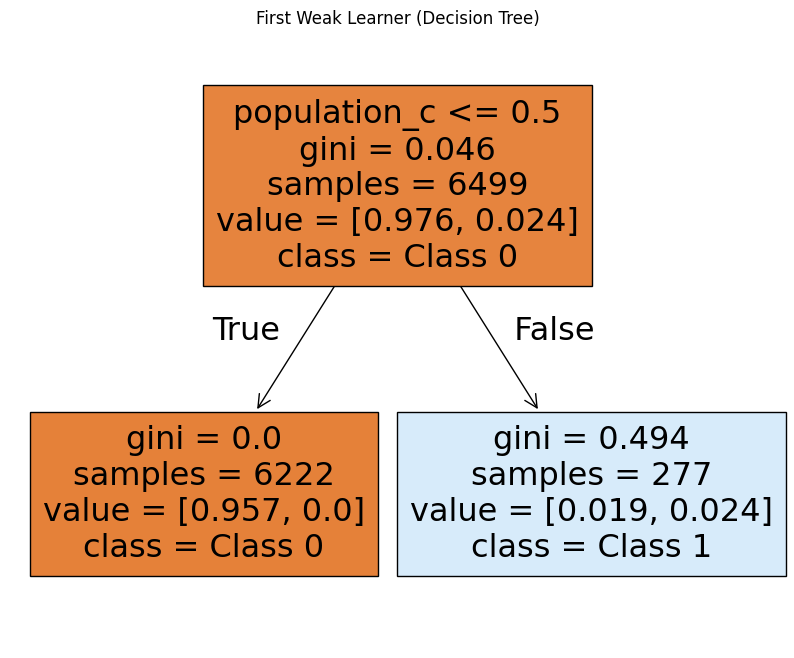

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_tree(
    best_model.estimators_[0],
    feature_names=X.columns,
    class_names=["Class 0", "Class 1"],
    filled=True
)
plt.title("First Weak Learner (Decision Tree)")
plt.show()

**Plot Feature Importance**

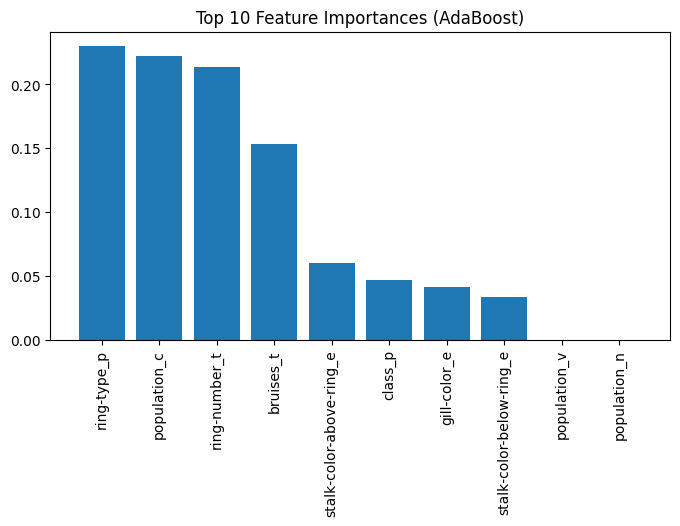

In [20]:
import numpy as np
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,4))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), X.columns[indices], rotation=90)
plt.title("Top 10 Feature Importances (AdaBoost)")
plt.show()

**Model Evaluation**

In [11]:
print("Accuracy:", accuracy_score(Y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_test_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00      1587
        True       1.00      1.00      1.00        38

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


Confusion Matrix:
 [[1587    0]
 [   0   38]]


**Conclusion**

The AdaBoost ensemble model was implemented for mushroom classification and evaluated using standard metrics. After hyperparameter tuning, the model achieved high accuracy on both training and testing data. The results show that AdaBoost effectively improves classification performance by combining multiple weak learners and focusing on misclassified samples.